# **FlightOnTime**
###La API que precide el retraso de vuelos
---

##Importación de librerías a utilizar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
import pickle
import joblib


##Ingresando dataframe a la variable datos

In [ ]:
datos = pd.read_csv('/content/flights_sample_3m.csv', engine='python');
datos.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


## Análisis EDA antes del preprocesamiento

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [ ]:
datos.describe(include = "all")

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3000000,3000000,3000000,3000000,3.000000e+06,3.000000e+06,3000000,3000000,3000000,3000000,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
unique,1704,18,18,18,NaN,NaN,380,373,380,373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2019-07-25,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,NaN,NaN,ATL,"Chicago, IL",ATL,"Chicago, IL",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2379,576470,576470,576470,NaN,NaN,153556,157368,153569,158087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.997629e+04,2.511536e+03,NaN,NaN,NaN,NaN,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,NaN,NaN,NaN,NaN,3.772846e+02,1.747258e+03,NaN,NaN,NaN,NaN,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,NaN,NaN,NaN,NaN,1.939300e+04,1.000000e+00,NaN,NaN,NaN,NaN,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,1.979000e+04,1.051000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,1.993000e+04,2.152000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,2.036800e+04,3.797000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000


###Limpiando Datos

In [ ]:
datos.isna().sum().sort_values(ascending=False)

,0
CANCELLATION_CODE,2920860
DELAY_DUE_LATE_AIRCRAFT,2466137
DELAY_DUE_CARRIER,2466137
DELAY_DUE_SECURITY,2466137
DELAY_DUE_NAS,2466137
DELAY_DUE_WEATHER,2466137
ARR_DELAY,86198
ELAPSED_TIME,86198
AIR_TIME,86198
WHEELS_ON,79944


In [ ]:
datos.isna().sum().sort_values(ascending=False) * 100

,0
CANCELLATION_CODE,292086000
DELAY_DUE_LATE_AIRCRAFT,246613700
DELAY_DUE_CARRIER,246613700
DELAY_DUE_SECURITY,246613700
DELAY_DUE_NAS,246613700
DELAY_DUE_WEATHER,246613700
ARR_DELAY,8619800
ELAPSED_TIME,8619800
AIR_TIME,8619800
WHEELS_ON,7994400


In [ ]:
datos['DEP_DELAY'] = datos['DEP_DELAY'].fillna(0)

In [ ]:
datos[datos['CANCELLED'] == 1].isna().sum()

,0
FL_DATE,0
AIRLINE,0
AIRLINE_DOT,0
AIRLINE_CODE,0
DOT_CODE,0
FL_NUMBER,0
ORIGIN,0
ORIGIN_CITY,0
DEST,0
DEST_CITY,0


###Dividir los vuelos operados de los cancelados

In [ ]:
vuelos_cancelados = datos.loc[datos['CANCELLED'] == 1].copy()
vuelos_operados = datos.loc[datos['CANCELLED'] == 0].copy()
vuelos_operados['FL_DATE'] = pd.to_datetime(vuelos_operados['FL_DATE'], errors='coerce')

In [ ]:
# Verificando si hay fechas invalidas (NaT) despues de la conversion
vuelos_operados[vuelos_operados['FL_DATE'].isna()]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT


In [ ]:
#Retrasos
vuelos_operados[
    (vuelos_operados['DEP_DELAY'] < -60) |
    (vuelos_operados['DEP_DELAY'] > 1000)
]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
29,2023-04-15,Republic Airline,Republic Airline: YX,YX,20452,3615,MSP,"Minneapolis, MN",EWR,"Newark, NJ",...,0.0,178.0,233.0,145.0,1008.0,0.0,0.0,1124.0,0.0,0.0
3639,2021-12-30,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,696,SLC,"Salt Lake City, UT",LAX,"Los Angeles, CA",...,0.0,120.0,125.0,90.0,590.0,1022.0,0.0,5.0,0.0,0.0
4548,2019-12-20,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1646,RSW,"Fort Myers, FL",CLT,"Charlotte, NC",...,0.0,120.0,105.0,83.0,600.0,1020.0,0.0,0.0,0.0,0.0
5147,2021-02-01,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2228,CLT,"Charlotte, NC",EWR,"Newark, NJ",...,0.0,117.0,122.0,76.0,529.0,0.0,1180.0,5.0,0.0,0.0
13746,2021-10-04,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,3230,SEA,"Seattle, WA",LAX,"Los Angeles, CA",...,0.0,169.0,162.0,136.0,954.0,0.0,0.0,0.0,0.0,1049.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2974756,2021-02-15,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5077,EAU,"Eau Claire, WI",ORD,"Chicago, IL",...,0.0,74.0,80.0,53.0,269.0,0.0,1086.0,0.0,0.0,0.0
2983586,2020-07-07,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,5512,GJT,"Grand Junction, CO",DEN,"Denver, CO",...,0.0,70.0,84.0,39.0,212.0,1470.0,0.0,0.0,0.0,0.0
2990081,2020-02-16,Allegiant Air,Allegiant Air: G4,G4,20368,867,PIA,"Peoria, IL",PIE,"St. Petersburg, FL",...,0.0,135.0,141.0,124.0,965.0,955.0,0.0,6.0,0.0,415.0
2990925,2022-03-09,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2216,PDX,"Portland, OR",DFW,"Dallas/Fort Worth, TX",...,0.0,226.0,213.0,186.0,1616.0,1859.0,0.0,0.0,0.0,0.0


In [ ]:
vuelos_operados[
    (vuelos_operados['DISTANCE'] <= 0) |
    (vuelos_operados['DISTANCE'] > 15000)
]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT


### Transformación de tipo de dato



In [ ]:
#La variable distance se encuentra el millas
vuelos_operados['DISTANCE'].describe()

,DISTANCE
count,2.920860e+06
mean,8.110854e+02
std,5.895143e+02
min,2.900000e+01
25%,3.790000e+02
50%,6.550000e+02
75%,1.047000e+03
max,5.812000e+03


### Convirtiendo a Kilometros

In [ ]:
vuelos_operados['DISTANCE_KM'] = vuelos_operados['DISTANCE'] * 1.60934
vuelos_operados['DISTANCE_KM'].describe()

,DISTANCE_KM
count,2.920860e+06
mean,1.305312e+03
std,9.487289e+02
min,4.667086e+01
25%,6.099399e+02
50%,1.054118e+03
75%,1.684979e+03
max,9.353484e+03


### Graficando variables

### Cancelaciones por aerolinea (en caso de que sea relevante)

<Axes: xlabel='AIRLINE'>

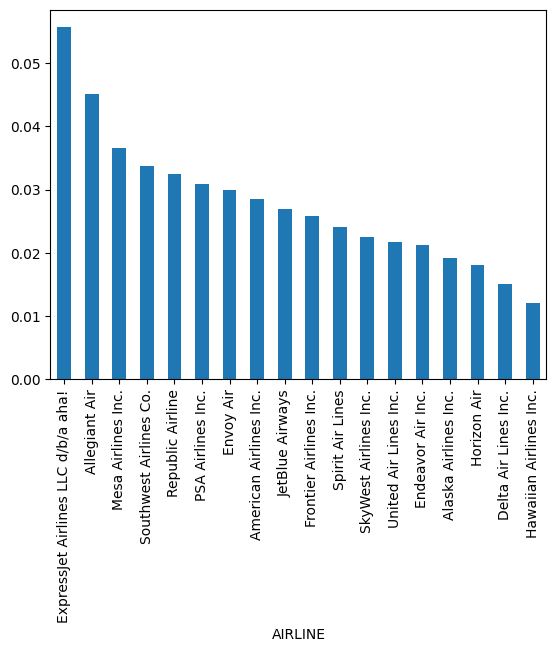

In [ ]:
tasa_cancelacion = (
    datos.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=False)
)
tasa_cancelacion.plot(kind='bar')

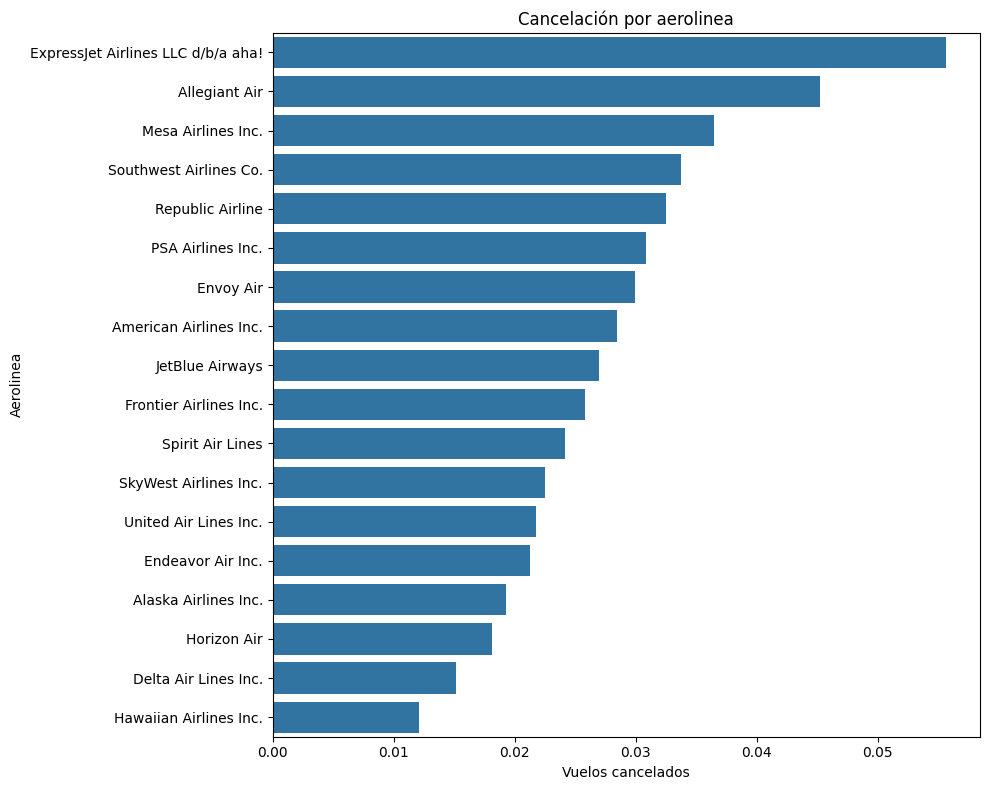

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(
    y=tasa_cancelacion.index,
    x=tasa_cancelacion.values,
    orient='h'
)
plt.title("Cancelación por aerolinea")
plt.xlabel("Vuelos cancelados")
plt.ylabel("Aerolinea")
plt.tight_layout()
plt.show()

### Retrasos por aerolinea

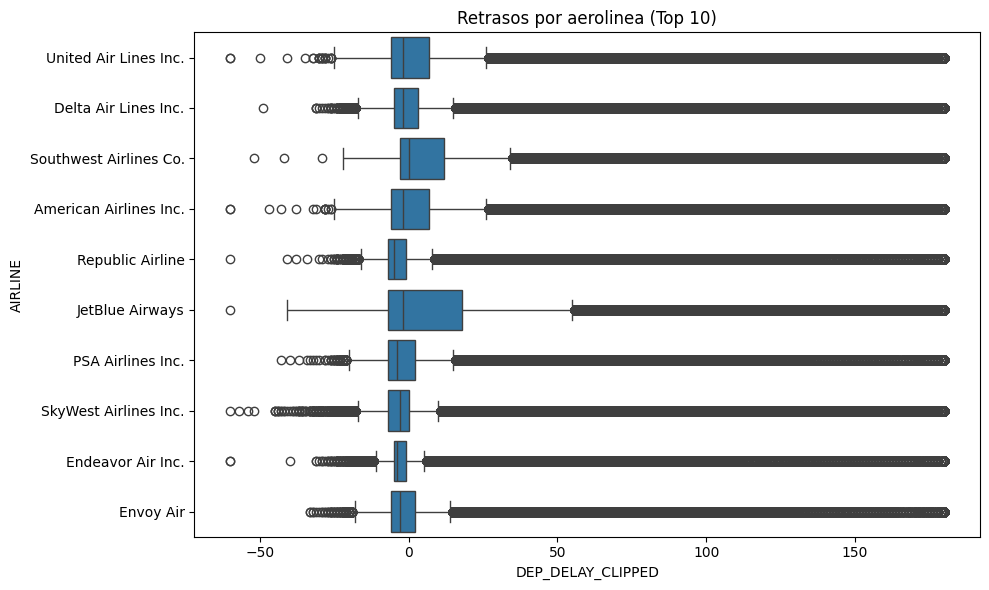

In [ ]:
top_aerolineas = (vuelos_operados['AIRLINE'].value_counts().head(10).index)

datos_top = vuelos_operados[vuelos_operados['AIRLINE'].isin(top_aerolineas)].copy()

datos_top.loc[:, 'DEP_DELAY_CLIPPED'] = datos_top['DEP_DELAY'].clip(lower=-60, upper=180)

plt.figure(figsize=(10,6))
sns.boxplot(data=datos_top, y='AIRLINE', x='DEP_DELAY_CLIPPED')
plt.title('Retrasos por aerolinea (Top 10)')
plt.tight_layout()
plt.show()

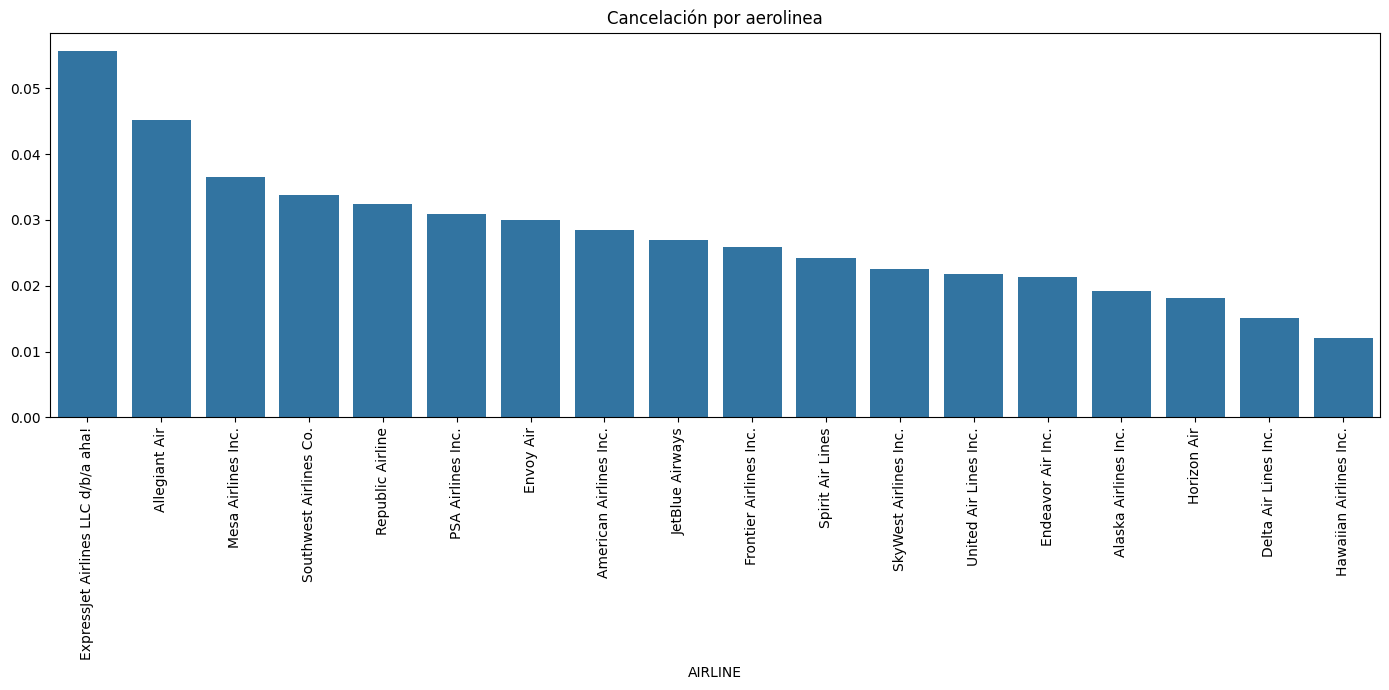

In [ ]:
# En graficas en vertical

plt.figure(figsize=(14,7))
sns.barplot(x=tasa_cancelacion.index, y=tasa_cancelacion.values)
plt.xticks(rotation=90)
plt.title('Cancelación por aerolinea')
plt.tight_layout()
plt.show()

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

## Feature engeeniering

###Extracción  de variables temporales

In [ ]:
#Hora del día
#Dividimos DEP_TIME por 100 para obtener la hora y luego rellenamos nulos
vuelos_operados['DEP_TIME_HOUR'] = (vuelos_operados['DEP_TIME'] // 100).fillna(0).astype(int)

#Día de la semana
#Para que dt.dayofweek nos devuelva 0 = Lunes, 1 = Martes, 2 Miércoles ... 6 = domingo
print(f"FL_DATE dtype before .dt accessor: {vuelos_operados['FL_DATE'].dtype}")
vuelos_operados['DAY_OF_WEEK'] = vuelos_operados['FL_DATE'].dt.dayofweek

#Mes del año
#Extraemos el mes (1=Enero | 12=Diciembre)
vuelos_operados['MONTH'] = vuelos_operados['FL_DATE'].dt.month

print("Ejemplo de nuevas variables temporales:")
print(vuelos_operados[['FL_DATE', 'DEP_TIME', 'DEP_TIME_HOUR', 'DAY_OF_WEEK', 'MONTH']].head())

FL_DATE dtype before .dt accessor: datetime64[ns]
Ejemplo de nuevas variables temporales:
     FL_DATE  DEP_TIME  DEP_TIME_HOUR  DAY_OF_WEEK  MONTH
0 2019-01-09    1151.0             11            2      1
1 2022-11-19    2114.0             21            5     11
2 2022-07-22    1000.0             10            4      7
3 2023-03-06    1608.0             16            0      3
4 2020-02-23    1838.0             18            6      2


###Codificación de variables categóricas (Label Encoding)

In [ ]:
#Iniciamos los codificadores respectivos
le_aerolinea = LabelEncoder()
le_origen = LabelEncoder()
le_destino = LabelEncoder()

#Entrenamos y transformamos al mismo tiempo
vuelos_operados['aerolinea_encoded'] = le_aerolinea.fit_transform(vuelos_operados['AIRLINE_CODE'])
vuelos_operados['origen_encoded'] = le_origen.fit_transform(vuelos_operados['ORIGIN'])
vuelos_operados['destino_encoded'] = le_destino.fit_transform(vuelos_operados['DEST'])

print("Ejemplo de nuevas variables codificadas:")
print(vuelos_operados[['AIRLINE_CODE', 'aerolinea_encoded', 'ORIGIN', 'origen_encoded', 'DEST', 'destino_encoded']].head())



Ejemplo de nuevas variables codificadas:
  AIRLINE_CODE  aerolinea_encoded ORIGIN  origen_encoded DEST  destino_encoded
0           UA                 14    FLL             131  EWR              123
1           DL                  4    MSP             247  SEA              323
2           UA                 14    DEN              99  MSP              247
3           DL                  4    MSP             247  SFO              325
4           NK                 10    MCO             223  DFW              100


###Creación de diccionario con los números a códigos de líneas aéreas

In [ ]:
#Diccionario general que vinculan los códigos originales de las aerolíneas
#y aeropuertos con los identificadores numéricos generados por los LabelEncoder.

#Este "mapa de traducción" que permite que el microservicio convierta instantáneamente
#las entradas de texto del usuario en los valores exactos que el modelo requiere para procesar la predicción.
#Al exportar estas equivalencias y los codificadores mediante archivos .joblib, se garantiza que el sistema
#hable un único idioma técnico y elimino cualquier riesgo de error en la comunicación de datos entre la API y el modelo entrenado.

#Obtenemos las clases (los códigos originales ordenados)
#El índice de la lista es el número asignado por el encoder.
codigos = le_aerolinea.classes_

#Creamos el diccionario: { Número : "Código" }
diccionario_num_a_codigo = {i: codigo for i, codigo in enumerate(codigos)}

#Creamos el diccionario inverso: { "Código" : Número }
diccionario_codigo_a_num = {codigo: i for i, codigo in enumerate(codigos)}

print("--- Diccionario: Número -> Aerolínea ---")
print(diccionario_num_a_codigo)

print("\n--- Diccionario: Aerolínea -> Número (Para la API) ---")
print(diccionario_codigo_a_num)

#'Opcional: Exportar a un archivo JSON real si el equipo de Backend lo prefiere'
with open('mapa_aerolineas.json', 'w') as f:
    json.dump(diccionario_codigo_a_num, f)
    print("\n Archivo 'mapa_aerolineas.json' exportado exitosamente.")

--- Diccionario: Número -> Aerolínea ---
{0: '9E', 1: 'AA', 2: 'AS', 3: 'B6', 4: 'DL', 5: 'EV', 6: 'F9', 7: 'G4', 8: 'HA', 9: 'MQ', 10: 'NK', 11: 'OH', 12: 'OO', 13: 'QX', 14: 'UA', 15: 'WN', 16: 'YV', 17: 'YX'}

--- Diccionario: Aerolínea -> Número (Para la API) ---
{'9E': 0, 'AA': 1, 'AS': 2, 'B6': 3, 'DL': 4, 'EV': 5, 'F9': 6, 'G4': 7, 'HA': 8, 'MQ': 9, 'NK': 10, 'OH': 11, 'OO': 12, 'QX': 13, 'UA': 14, 'WN': 15, 'YV': 16, 'YX': 17}

 Archivo 'mapa_aerolineas.json' exportado exitosamente.


##Determinación del target

###Creando variable objetivo binaria

In [ ]:
# Objetivo: Predecir la probabilidad de que un vuelo salga con retraso (DELAYED).
# Estándar Internacional (DOT/IATA): Un vuelo se considera retrasado (1) si presenta
# una demora en la salida (DEP_DELAY) >= 15 minutos; de lo contrario es a tiempo (0).
# Criterios de Limpieza y Validación:
# 1. Se incluyen solo vuelos operados (no cancelados ni desviados).
# 2. Se eliminan registros sin información en DEP_DELAY para asegurar la consistencia del target.
# 3. Se verifican valores extremos para garantizar que la definición sea representativa.

# Trabajamos sobre el 'vuelos_operados' que ya viene con features.

# 1. Eliminar registros sin DEP_DELAY (Limpieza necesaria para el target)
vuelos_operados = vuelos_operados.dropna(subset=['DEP_DELAY']).copy()

# 2. Crear el target binario
vuelos_operados['DELAYED'] = (vuelos_operados['DEP_DELAY'] >= 15).astype(int)

# 3. Revisión rápida del balance de clases
print(vuelos_operados['DELAYED'].value_counts(normalize=True))

DELAYED
0    0.818193
1    0.181807
Name: proportion, dtype: float64


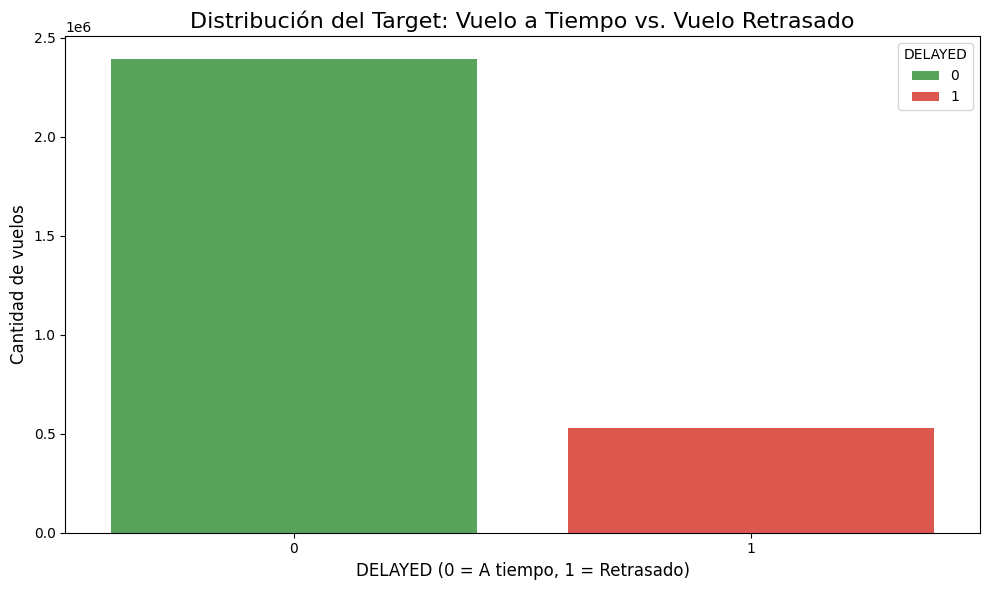

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='DELAYED',
    hue='DELAYED',
    data=vuelos_operados,
    palette=['#4CAF50', '#F44336']  # Verde = a tiempo, rojo = retrasado
   )

plt.title('Distribución del Target: Vuelo a Tiempo vs. Vuelo Retrasado', fontsize=16)
plt.xlabel('DELAYED (0 = A tiempo, 1 = Retrasado)', fontsize=12)
plt.ylabel('Cantidad de vuelos', fontsize=12)

# Conclusión técnica: Se confirma un desbalance de clases (~18% de retrasos).
# Esta proporción justifica el uso de 'class_weight=balanced' y el muestreo
# estratificado para asegurar que el modelo aprenda correctamente de la clase minoritaria.

plt.tight_layout()
plt.show()

### Interpretación del gráfico

En el gráfico se puede ver claramente cómo se distribuyen los vuelos entre aquellos que salen a tiempo (`DELAYED = 0`) y los que presentean un retraso de 15 minutos o más (`DELAYED = 1`).

La revisión es fundamental porque:

- Permite detectar si existe un desbalance entre ambasclases, algo que más adelante influirá en las métricas y en las decisiones de modelado.
- También confirma que la construcción del target es coherente con los datos disponibles.
- Además asegura que el modelo se entrenará con información representativa de la operación real, lo que aumenta la confiabilidad de los resultados.

Con esta etapa, la determinación del target queda completamente definida y validada.


###Validando que las features coincidan con el contrato de la API

In [ ]:
#Definimos las columnas esenciales para el modelo
columnas_features = [
    'DEP_TIME_HOUR',
    'DAY_OF_WEEK',
    'MONTH',
    'aerolinea_encoded',
    'origen_encoded',
    'destino_encoded',
    'DISTANCE_KM']

# Verificamos que no queden nulos residuales en estas columnas específicas
vuelos_operados = vuelos_operados.dropna(subset=columnas_features + ['DELAYED'])
X = vuelos_operados[columnas_features]
y = vuelos_operados['DELAYED']

#Entrenamiento del modelo


###Definición de columnas predictoras y variables


In [ ]:
#1.Definir las columnas predictoras (features)
#*CORRECCIÓN* Agregadas las features de tiempo para el entrenamiento
cols_existentes = [
    'aerolinea_encoded',
    'origen_encoded',
    'destino_encoded',
    'DISTANCE_KM',
    'DAY_OF_WEEK',
    'DEP_TIME_HOUR',
    'MONTH'
]

#Verificamos que estas columnas existan realmente en el dataframe
columnas_finales = [c for c in cols_existentes if c in vuelos_operados.columns]

#2.Limpieza final de nulos
#Eliminamos filas que tengan nulos 'solo' en las columnas que vamos a usar o en el target
#*Nota* Usamos 'DELAYED' que creo Fabiola previamente (target: 0 o 1)
vuelos_operados = vuelos_operados.dropna(subset=columnas_finales + ['DELAYED'])

#3.Definición de X (Variables) e y (Target)
X = vuelos_operados[columnas_finales].copy()
y = vuelos_operados['DELAYED'].copy() # Usamos la columna ya calculada previamente (0=Puntual, 1=Retrasado)

#Validaciones de seguridad
#Aseguramos que los tipos de datos sean numéricos
for col in ['DISTANCE_KM', 'DAY_OF_WEEK', 'DEP_TIME_HOUR', 'MONTH']:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

#Volvemos a limpiar nulos por si la conversión generó alguno (ej: textos en columna numérica)
X = X.dropna()
y = y.loc[X.index] #Alineamos el target con las filas

print("--- Preparación lista ---")
print(f"Registros finales para entrenar: {len(X)}")
print(f"Columnas utilizadas: {X.columns.tolist()}")
display(X.head())

--- Preparación lista ---
Registros finales para entrenar: 2920860
Columnas utilizadas: ['aerolinea_encoded', 'origen_encoded', 'destino_encoded', 'DISTANCE_KM', 'DAY_OF_WEEK', 'DEP_TIME_HOUR', 'MONTH']


,aerolinea_encoded,origen_encoded,destino_encoded,DISTANCE_KM,DAY_OF_WEEK,DEP_TIME_HOUR,MONTH
0,14,131,123,1713.94710,2,11,1
1,4,247,323,2251.46666,5,21,11
2,14,99,247,1094.35120,4,10,7
3,4,247,325,2557.24126,0,16,3
4,10,223,100,1585.19990,6,18,2


###Separación de los datos de entrenamiento y prueba para el modelo



In [ ]:
#1.Optimización de RAM para subir de 10% a 20%
#Convertimos tipos de datos 64 bits a 8/16/32 bits para aligerar la carga
def optimizar_memoria(df):
  for col in df.columns:
    col_type = df[col].dtypes
    if str(col_type)[:3] == 'int':
      c_min, c_max = df[col].min(), df[col].max()
      if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
        df[col] = df[col].astype(np.int8)
      elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
        df[col] = df[col].astype(np.int16)
      elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
        df[col] = df[col].astype(np.int32)
    elif str(col_type)[:5] == 'float':
        df[col] = df[col].astype(np.float32)
  return df
print("Optimizando memoria")
X = optimizar_memoria(X)
print("Optimización lista")

#2.Sampling estratificado del nuevo 20%
#Cambiamos de '.sample' a train_test_split para mantener el balance de clases del target (20 vs 80)
porcentaje_sample = 0.20

#Se aplica un muestreo del 20% para estabilidad y velocidad del MVP
#Utilizamos el stratify=y en el caso de que existan 18% de retrasos, el sample los mantenga exactos
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=porcentaje_sample,
    random_state=42,
    stratify=y
)

#Separación de los datos de entrenamiento y prueba, 80% para entrenamiento y 20% para prueba de los modelos
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)
print("Datos separados, balanceados y optimizados")

Optimizando memoria
Optimización lista
Datos separados, balanceados y optimizados


###Entrenando modelos predictores

In [ ]:

#1.Logistic Regression
#Probamos solo la "fuerza" de regularización (C)
param_log = {'C': [0.1, 1.0, 10]}

print("Entrenando Logistic Regression")
#Usamos RandomizedSearch aunque sea pequeño para mantener el estándar
rand_log = RandomizedSearchCV(
    LogisticRegression(max_iter=500, class_weight='balanced', solver='lbfgs', n_jobs=2),
    param_distributions=param_log,
    n_iter=3, #Prueba las 3 opciones
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=2 #Usamos solo 2 núcleos para evitar bloqueos en Colab
)
rand_log.fit(X_train, y_train)
modelo_log_final = rand_log.best_estimator_

#2. Random Forest
#Definimos rangos para que el algoritmo "determine" valores
param_rf_dist = {
    'n_estimators': [50],        #Menos árboles para velocidad
    'max_depth': [10, 15],            #Profundidad controlada
    'min_samples_split': [5, 10]   #Evita sobreajuste
}

print("Entrenando Random Forest")
rand_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_rf_dist,
    n_iter=2,  #Solo probará 2 combinaciones aleatorias, no todas.
    cv=3,      #3 validaciones por intento
    scoring='f1',
    n_jobs=2,  #Seguro para Colab
    random_state=42
)
rand_rf.fit(X_train, y_train)
modelo_rf_final = rand_rf.best_estimator_

print(f"Entrenamiento finalizado")
print(f"Mejores parámetros RF: {rand_rf.best_params_}")

Entrenando Logistic Regression
Entrenando Random Forest
Entrenamiento finalizado
Mejores parámetros RF: {'n_estimators': 50, 'min_samples_split': 10, 'max_depth': 15}


#Evaluación de los modelos

--- TABLA COMPARATIVA DE RENDIMIENTO ---


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6142,0.2653,0.6338,0.3740,0.6670
1,Random Forest,0.7106,0.3271,0.5596,0.4129,0.7218



--- DETALLE VISUAL DE ERRORES (Matrices de Confusión) ---


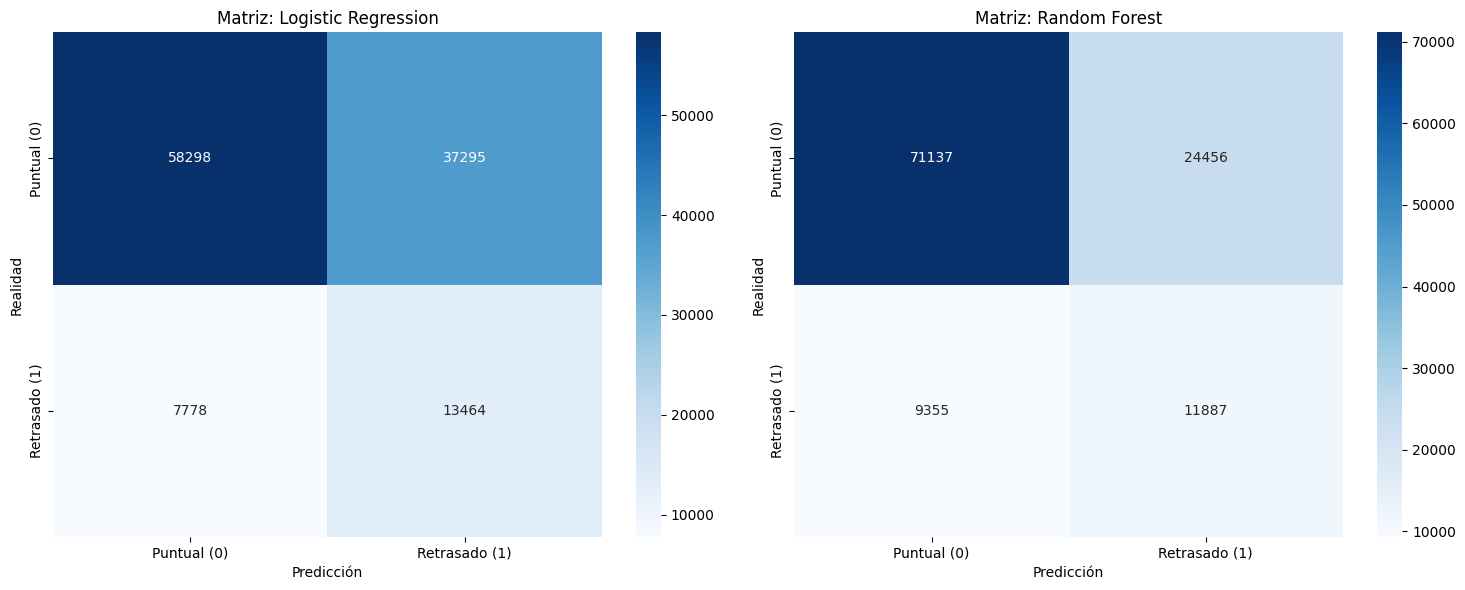


--- REPORTE DETALLADO DEL MEJOR MODELO (Random Forest) ---
              precision    recall  f1-score   support

           0       0.88      0.74      0.81     95593
           1       0.33      0.56      0.41     21242

    accuracy                           0.71    116835
   macro avg       0.61      0.65      0.61    116835
weighted avg       0.78      0.71      0.74    116835



In [ ]:
def obtener_metricas(nombre, modelo, X_test, y_test):
    #Predicciones binarias (0 o 1)
    preds = modelo.predict(X_test)
    #Probabilidades (para ROC-AUC) - Usamos la columna 1 (Probabilidad de retraso)
    try:
        probs = modelo.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, probs)
    except:
        roc = 0 # Por si algún modelo no tiene predict_proba

    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc
    }

#1.Calculamos métricas para ambos modelos (ya entrenados en el paso anterior)
#*Nota* modelo_log_final y modelo_rf_final vienen de la celda de RandomizedSearchCV
metricas_log = obtener_metricas('Logistic Regression', modelo_log_final, X_test, y_test)
metricas_rf = obtener_metricas('Random Forest', modelo_rf_final, X_test, y_test)

#2.Tabla comparativa
tabla_comparativa = pd.DataFrame([metricas_log, metricas_rf])
print("--- TABLA COMPARATIVA DE RENDIMIENTO ---")
display(tabla_comparativa.round(4)) # Redondeamos a 4 decimales para limpieza

#3.Visualización de matrices de confusión (Lado a Lado)
print("\n--- DETALLE VISUAL DE ERRORES (Matrices de Confusión) ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

modelos_visualizar = [
    ('Logistic Regression', modelo_log_final, axes[0]),
    ('Random Forest', modelo_rf_final, axes[1])
]

for nombre, modelo, ax in modelos_visualizar:
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Puntual (0)', 'Retrasado (1)'],
                yticklabels=['Puntual (0)', 'Retrasado (1)'])
    ax.set_title(f'Matriz: {nombre}')
    ax.set_ylabel('Realidad')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.show()

#4.Reporte detallado del GANADOR (Random Forest por defecto)
print("\n--- REPORTE DETALLADO DEL MEJOR MODELO (Random Forest) ---")
print(classification_report(y_test, modelo_rf_final.predict(X_test)))

#Matriz de confusión

--- Reporte completo de clasificación ---
              precision    recall  f1-score   support

           0       0.88      0.74      0.81     95593
           1       0.33      0.56      0.41     21242

    accuracy                           0.71    116835
   macro avg       0.61      0.65      0.61    116835
weighted avg       0.78      0.71      0.74    116835



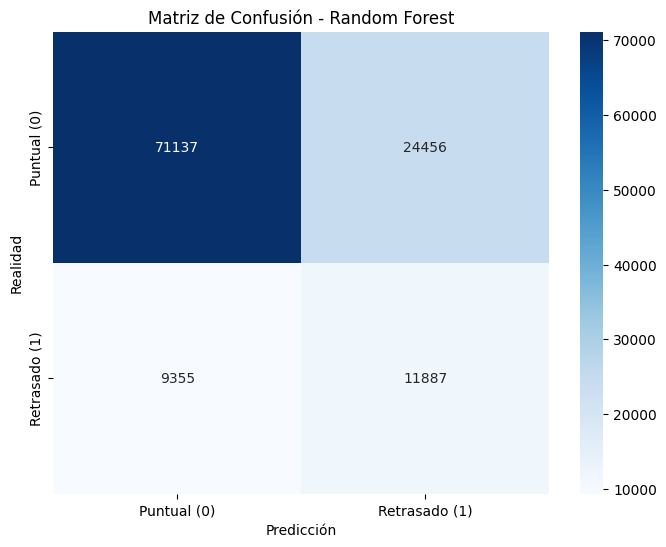

In [ ]:
#Usamos el modelo final de Random Forest
y_pred = modelo_rf_final.predict(X_test)

print("--- Reporte completo de clasificación ---")
print(classification_report(y_test, y_pred))

#Visualización gráfica de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
#Annot=True muestra los números, fmt='d' formato entero, cmap='Blues' color azul
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Puntual (0)', 'Retrasado (1)'],
            yticklabels=['Puntual (0)', 'Retrasado (1)'])
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

##El modelo seleccionado es el Random Forest

1. Superioridad en métricas globales

-Accuracy: Logró un 71.06% de acierto general frente al 61.42% del modelo base.

-ROC-AUC: Obtuvo un 0.7218, lo que indica una capacidad significativamente mayor para distinguir entre vuelos a tiempo y retrasados en comparación con el 0.6670 de la Regresión Logística.

-F1-Score: Presentó un balance superior de 0.4129, superando el 0.3740 de la alternativa.

2. Reducción de falsos positivos

-Precisión en vuelos puntuales: Identificó correctamente 71,137 vuelos a tiempo, mientras que la Regresión Logística solo acertó en 58,298.

-El Random Forest genera muchos menos falsos positivos (vuelos predichos como retrasados que realmente llegaron a tiempo), con solo 24,456 errores frente a los 37,295 de la Regresión Logística.

3. Justificación de negocio

Aunque el Recall es ligeramente menor (0.56 vs 0.63), el Random Forest ofrece un modelo mucho más estable y con una Precisión (0.3271) superior. Esto garantiza que las alertas enviadas al pasajero tengan una base más sólida, evitando la saturación de notificaciones erróneas y mejorando la credibilidad de la API.

# Serialización del Modelo

En esta sección se realiza la serialización del modelo entrenado junto con los encoders y el orden de las variables utilizadas.

Este proceso permite reutilizar el modelo en otros entornos sin necesidad de reentrenarlo, asegurando coherencia en la transformación de los datos y en la estructura de entrada esperada por el modelo.

In [ ]:
#1. Guardar el modelo entrenado
with open('modelo_entrenado.pkl', 'wb') as archivo:
    pickle.dump(modelo_rf_final, archivo)

#2. Guardar los encoders
with open ('encoder.pkl', 'wb') as archivo:
    pickle.dump({'le_aerolinea': le_aerolinea, 'le_origen': le_origen, 'le_destino': le_destino}, archivo)

# 3. Guardar el orden de las features
features_modelo = X_train.columns.tolist()
with open('features_modelo.pkl', 'wb') as archivo:
    pickle.dump(features_modelo, archivo)
print("Modelo, encoders y features guardados correctamente.")

Modelo, encoders y features guardados correctamente.
